# Exploratory Data Analysis (EDA)

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Load the ML Dataset

In [26]:
# Load the Barcelona noise ML dataset
dataset = pd.read_csv("data/bcn_noise_ml_subsample.csv")

print(f"Dataset shape: {dataset.shape}")
dataset.head()
print(dataset.columns.tolist())

Dataset shape: (11669, 13)
['road_id', 'noise_day', 'noise_evening', 'noise_night', 'road_length', 'road_category', 'dist_to_main', 'signals', 'transport', 'pois', 'width', 'betw_centrality', 'clos_centrality']


## Reduce the number of columns

In [27]:
print(dataset.columns.tolist())

['road_id', 'noise_day', 'noise_evening', 'noise_night', 'road_length', 'road_category', 'dist_to_main', 'signals', 'transport', 'pois', 'width', 'betw_centrality', 'clos_centrality']


<Axes: >

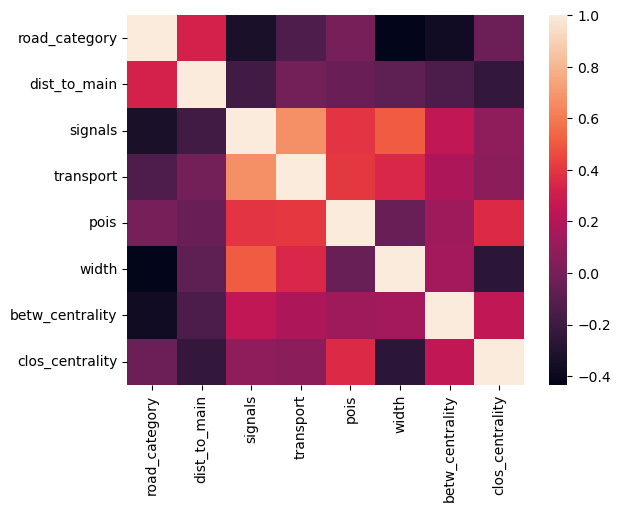

In [28]:
dataset_features = dataset.drop(columns=['road_id', 'road_length','noise_day', 'noise_evening', 'noise_night']) #dropping y and non-relevant columns
sns.heatmap(dataset_features.corr())

## Calculate Spearman correlation

Pearson measures linear relationships
-> very sensitive to outliers and nonlinear patterns

Spearman measures rank-order relationships
-> works well with nonlinear relationships and is more robust to outliers 

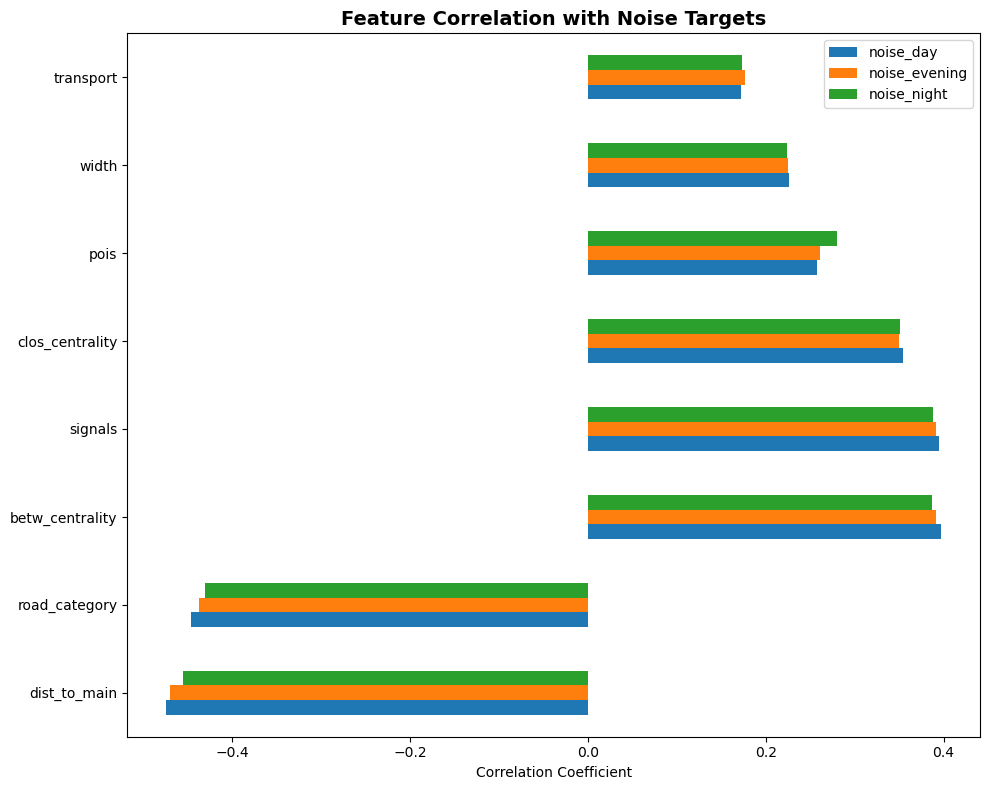

                 noise_day  noise_evening  noise_night
betw_centrality   0.397292       0.391549     0.386552
signals           0.395284       0.391076     0.387633
clos_centrality   0.354148       0.349558     0.350995
pois              0.257250       0.260742     0.280293
width             0.225699       0.225485     0.223826
transport         0.171808       0.177008     0.172970
road_category    -0.446911      -0.437609    -0.431215
dist_to_main     -0.474534      -0.469841    -0.455065


In [29]:
# Extract correlations with noise predictions
dataset_filtered = dataset.drop(columns=['road_id', 'road_length']) #dropping non-relevant columns
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method = 'spearman')[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax)
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

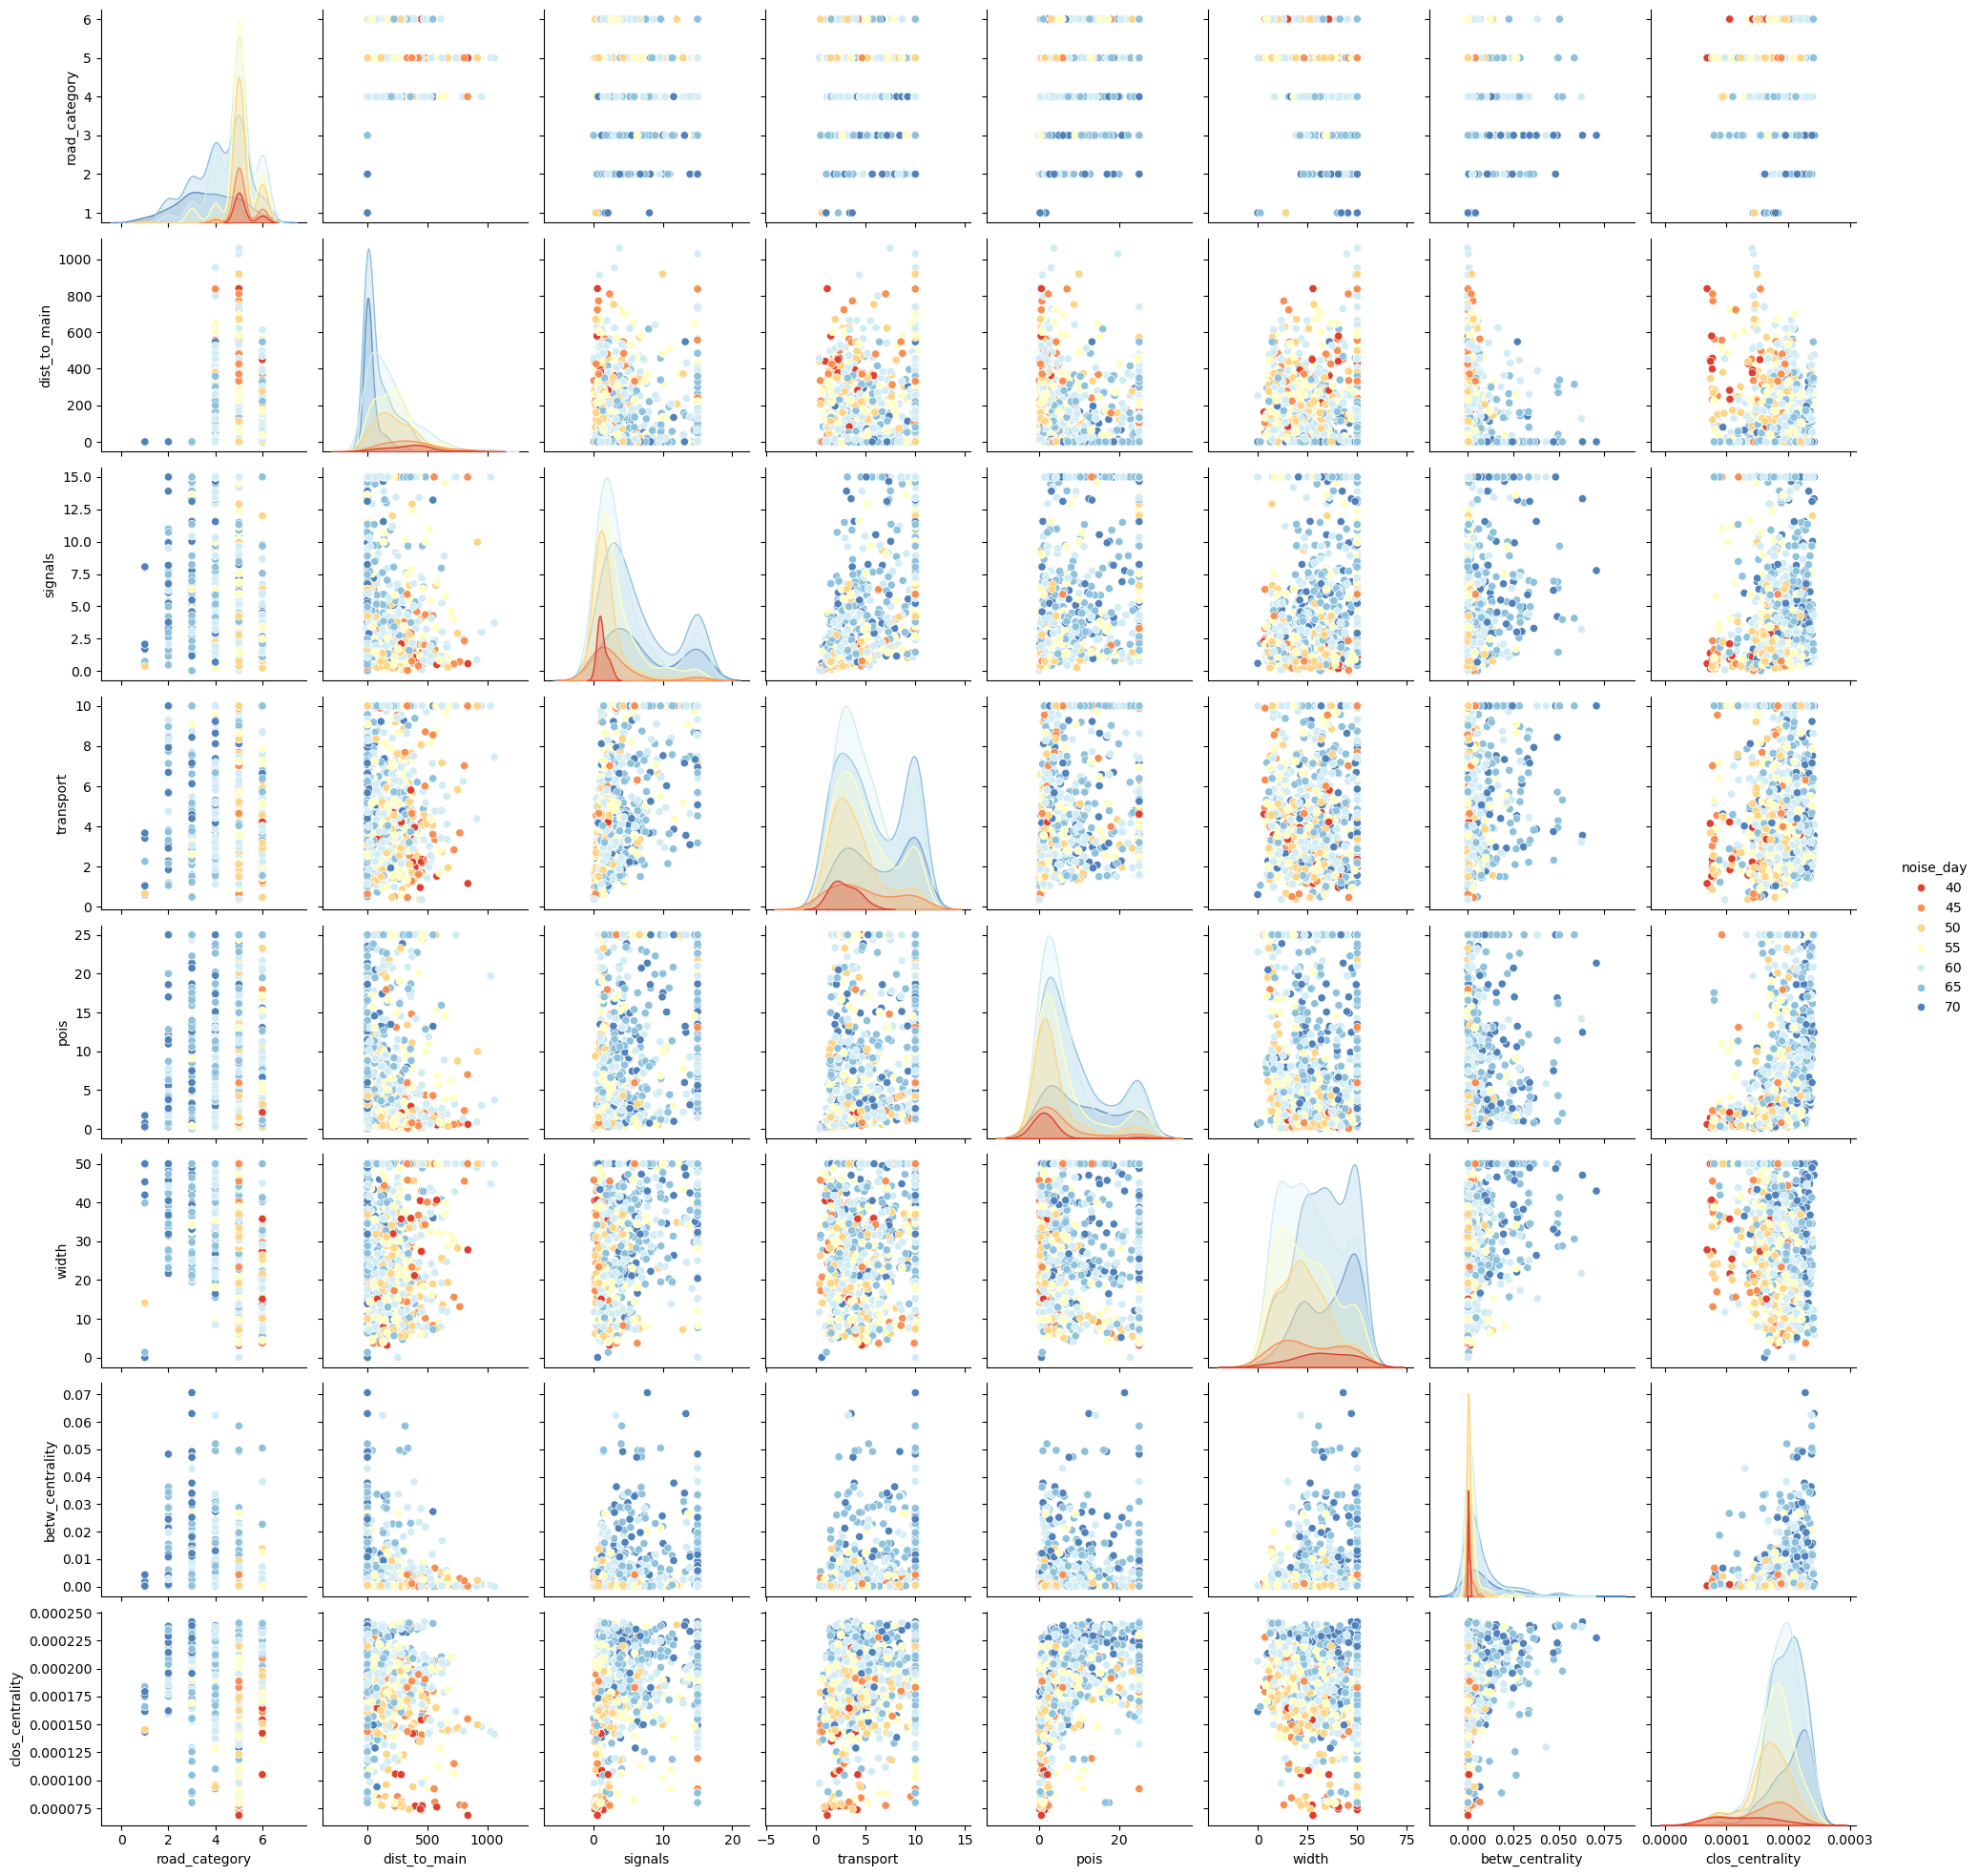

In [30]:
dataset_pairs = dataset.drop(columns=['road_id', 'road_length', 'noise_evening', 'noise_night']) 

# Sample randomly
sample = dataset_pairs.sample(n=1000, random_state=42).copy()

# Get unique noise_day values sorted and convert to ordered categorical
sorted_noise_values = sorted(sample['noise_day'].unique())
sample['noise_day'] = pd.Categorical(sample['noise_day'], categories=sorted_noise_values, ordered=True)

sns.pairplot(sample, hue="noise_day", palette="RdYlBu", corner=False)

In [31]:
# other plots tht can be
# histograms
# paralel coordinates plot
# boxplots/violonplots for distributions

In [32]:
print("Noise Day values:")
print(dataset['noise_day'].unique())
print("\nUnique values count:", dataset['noise_day'].nunique())


Noise Day values:
[55 60 65 40 50 70 45]

Unique values count: 7
